Plot saved as logs/error_analysis_plt_Aug17_19_28.fig.pickle
Data saved as logs/error_analysis_results_Aug17_19_28.csv


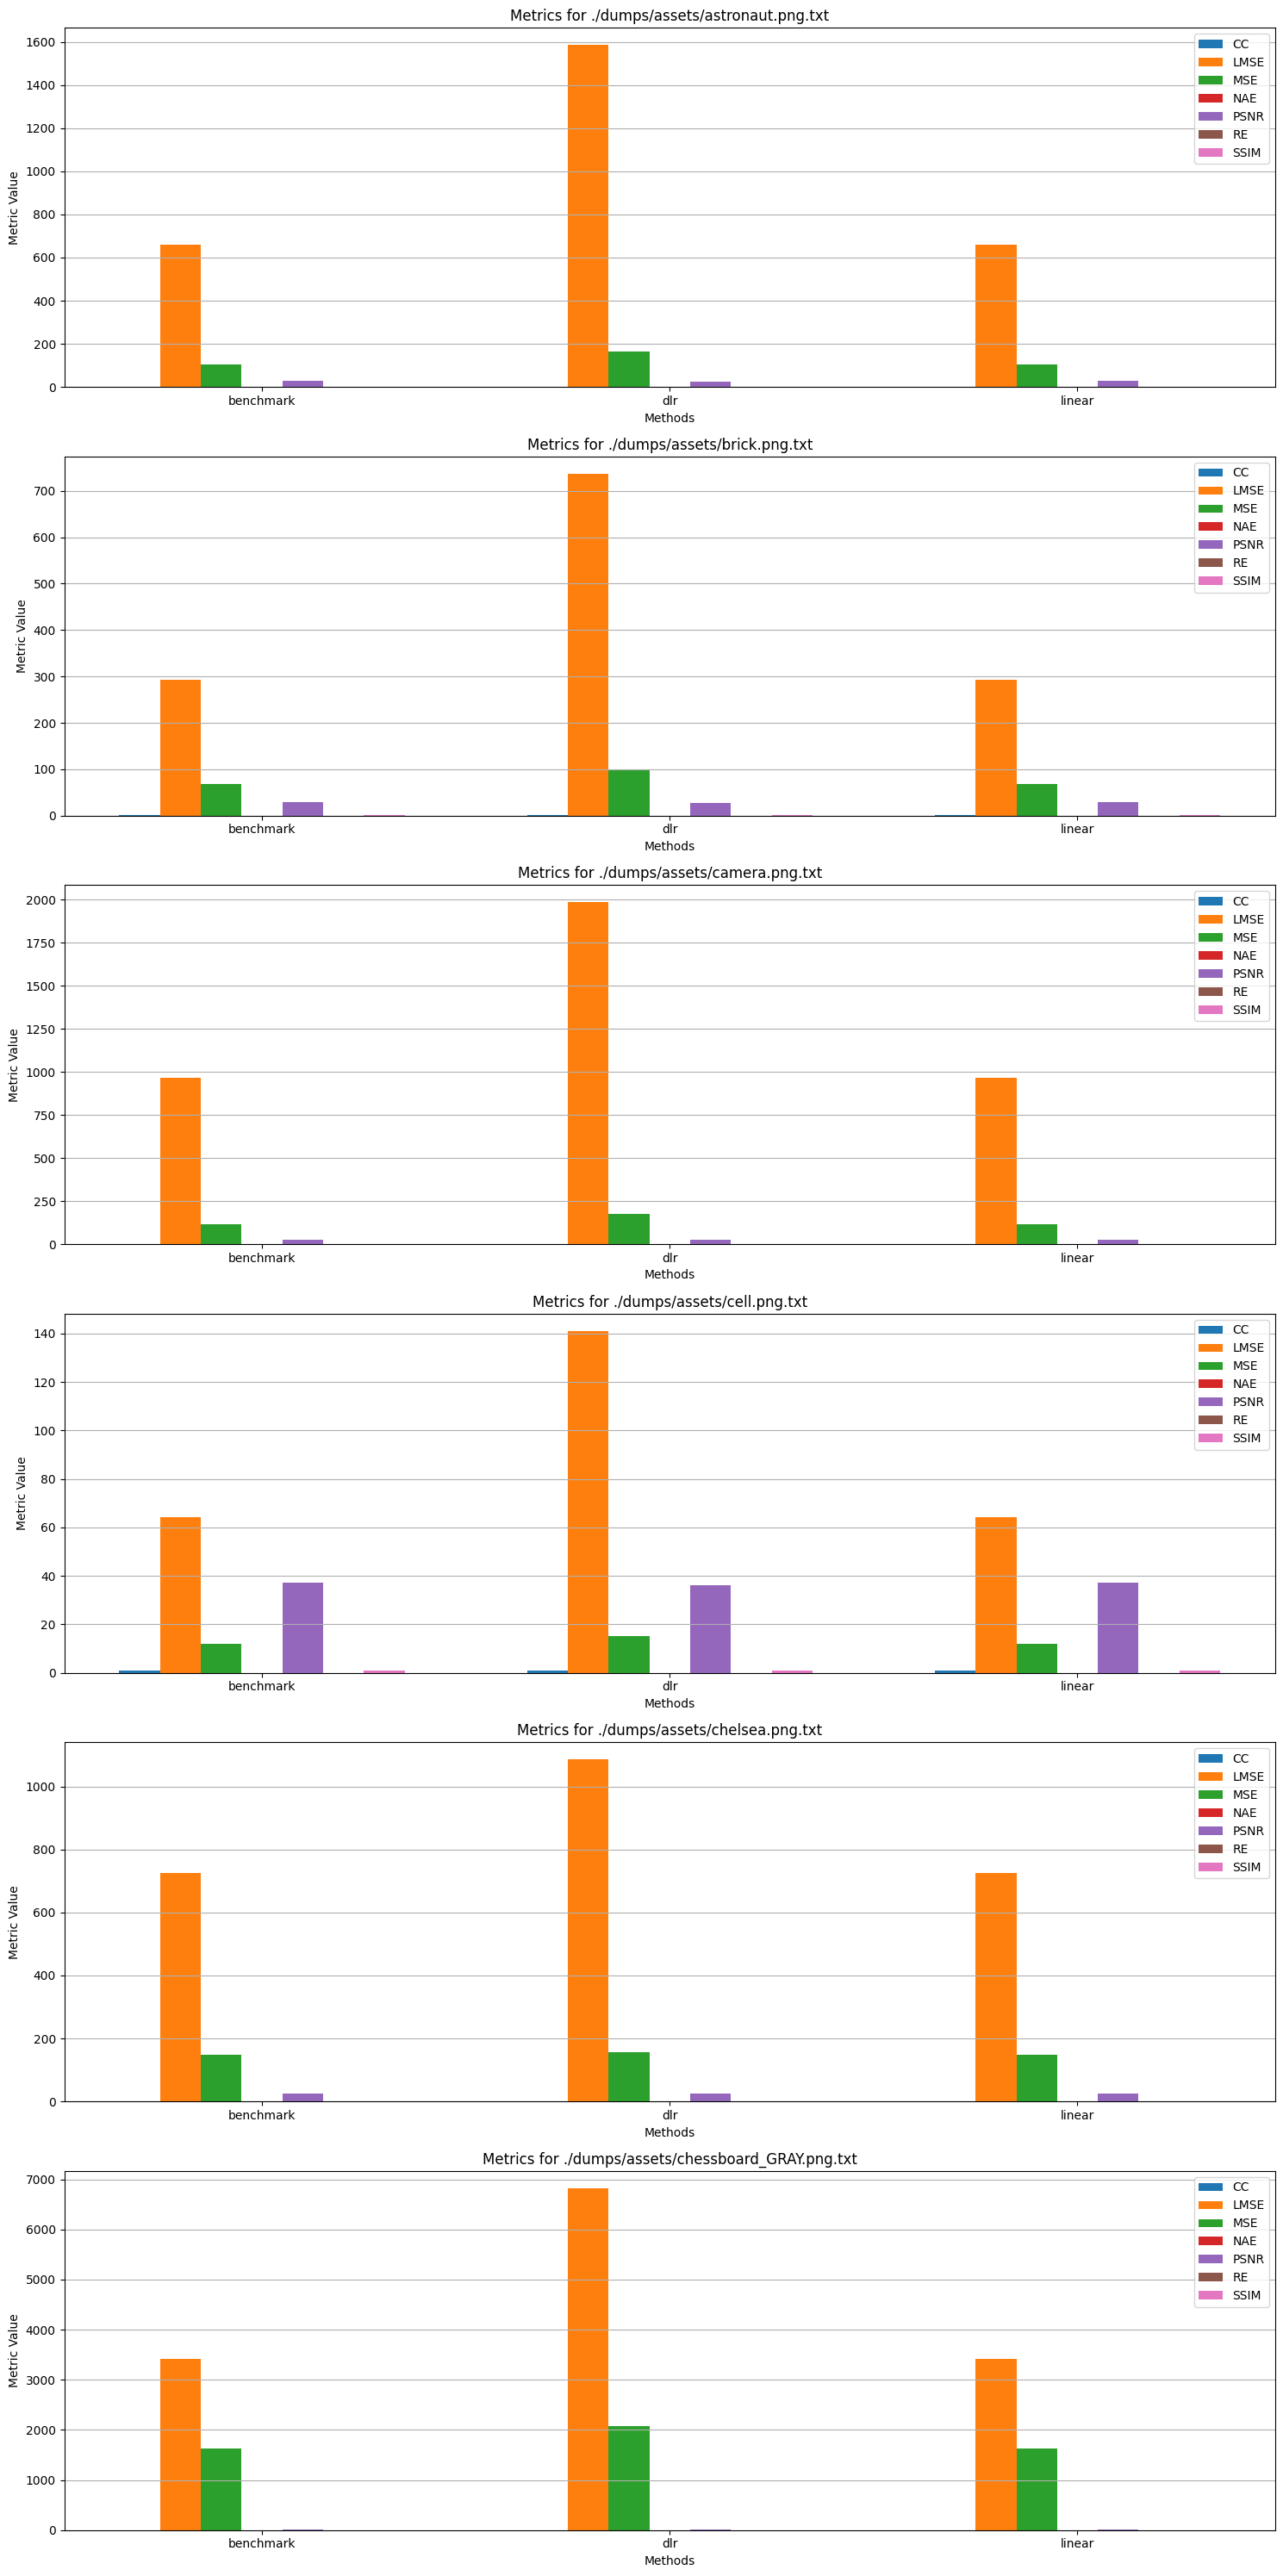

In [6]:
import json
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import csv
from datetime import datetime
import pickle


def psnr(original, processed):
    # mse = np.mean((original - processed) ** 2)
    # if mse == 0:
    #     return float('inf')
    # max_pixel_value = 255.0
    # psnr = 20 * np.log10(max_pixel_value / np.sqrt(mse))
    # return psnr
    return cv2.PSNR(original, processed)


def nae(original, processed):
    # Ensure the images are in floating point format to avoid integer overflow
    # original = original.astype(np.float64)
    # processed = processed.astype(np.float64)

    # Compute the NAE
    numerator = np.sum(np.abs(original - processed))
    denominator = np.sum(np.abs(original))

    return numerator / denominator


def cc(original, processed):
    original = original.flatten()
    processed = processed.flatten()
    cc = np.corrcoef(original, processed)[0, 1]
    return cc


# def cc(original, processed):
#     return np.sum(original * processed) / np.sum(original * original)


def lmse(original, processed):
    laplacian_original = cv2.Laplacian(original, cv2.CV_64F)
    laplacian_processed = cv2.Laplacian(processed, cv2.CV_64F)
    mse = np.mean((laplacian_original - laplacian_processed) ** 2)
    return mse


def mse(original, processed):
    # the 'Mean Squared Error' between the two images is the
    # sum of the squared difference between the two images;
    # NOTE: the two images must have the same dimension
    err = np.sum((original.astype("float") - processed.astype("float")) ** 2)
    err /= float(original.shape[0] * original.shape[1])

    # return the MSE, the lower the error, the more "similar"
    # the two images are
    return err


def re(original, processed):
    re = np.sum(np.abs(original - processed)) / np.sum(np.abs(original))
    return re


with open("logs/stuff_tested.json", mode="r", encoding="utf-8") as f:
    data = json.load(f)

results = {
    img: {
        "methods": [_.split("/")[-1][:-3] for _ in data["binaries"]],
        "PSNR": [],
        "NAE": [],
        "CC": [],
        "LMSE": [],
        "MSE": [],
        "RE": [],
        "SSIM": [],
    }
    for img in data["input_images"]
}

# Process each image and binary
for img_path in data["input_images"]:
    # original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    original_image = np.loadtxt(img_path).astype(np.float64)

    for method in results[img_path]["methods"]:
        # out_path = os.path.join(f"./outputs/{method}__b_{img_path.split('/')[-1]}")
        out_path = os.path.join(f"./dumps/out/{method}__b_{img_path.split('/')[-1]}")
        # processed_image = cv2.imread(out_path, cv2.IMREAD_GRAYSCALE)
        processed_image = np.loadtxt(out_path).astype(np.float64)

        # print(original_image.shape, processed_image.shape)
        max_w = max(original_image.shape[0], processed_image.shape[0])
        max_h = max(original_image.shape[1], processed_image.shape[1])

        target_shape = (max_w, max_h)
        og_new = np.zeros(target_shape)
        og_new[:original_image.shape[0], :original_image.shape[1]] = original_image

        processed_new = np.zeros(target_shape)
        processed_new[:processed_image.shape[0], :processed_image.shape[1]] = processed_image

        # print(og_new.shape, processed_new.shape)
        # if original_image.shape != processed_image.shape:
        #     raise ValueError("The two images must have the same dimensions")

        results[img_path]["PSNR"].append(psnr(og_new, processed_new))
        results[img_path]["NAE"].append(nae(og_new, processed_new))
        results[img_path]["CC"].append(cc(og_new, processed_new))
        results[img_path]["LMSE"].append(lmse(og_new, processed_new))
        results[img_path]["MSE"].append(mse(og_new, processed_new))
        results[img_path]["RE"].append(re(og_new, processed_new))
        results[img_path]["SSIM"].append(ssim(og_new, processed_new, data_range=og_new.max() - og_new.min()))
        # print(f"comparing {img_path} and {out_path}")


metrics = ["CC", "LMSE", "MSE", "NAE", "PSNR", "RE", "SSIM"]

num_images = len(results)
fig, axs = plt.subplots(num_images, 1, figsize=(15, 5 * num_images))

# Create directory for logs if it doesn't exist
os.makedirs('logs', exist_ok=True)

csv_filename = f'logs/error_analysis_results_{datetime.now().strftime("%b%d_%H_%M")}.csv'
csv_data = []

for idx, (image_name, image_data) in enumerate(results.items()):
    ax = axs[idx] if num_images > 1 else axs  # Handle case with only one subplot
    
    # Plot each metric as a bar graph
    bar_width = 0.1
    indices = np.arange(len(image_data['methods']))
    
    for i, metric in enumerate(metrics):
        values = image_data[metric]
        ax.bar(indices + i * bar_width, values, bar_width, label=metric)
    
    ax.set_xlabel('Methods')
    ax.set_ylabel('Metric Value')
    ax.set_title(f'Metrics for {image_name}')
    ax.set_xticks(indices + bar_width * (len(metrics) - 1) / 2)
    ax.set_xticklabels(image_data['methods'])
    ax.legend()
    ax.grid(True, axis='y')

# Adjust layout and save plot using pickle
plt.tight_layout()
pickle_filename = f'logs/error_analysis_plt_{datetime.now().strftime("%b%d_%H_%M")}.fig.pickle'
with open(pickle_filename, 'wb') as f:
    pickle.dump(fig, f)

with open(csv_filename, 'w', newline='') as f:
    writer = csv.writer(f)
    
    for image_name, image_data in results.items():
        writer.writerow([f'{image_name}:'])
        writer.writerow(['Metric'] + image_data['methods'])
        
        # Write the metrics as row headers and corresponding values
        for metric in metrics:
            row = [metric] + [image_data[metric][i] for i in range(len(image_data['methods']))]
            writer.writerow(row)
        
        writer.writerow([])

print(f"Plot saved as {pickle_filename}")
print(f"Data saved as {csv_filename}")

In [ ]:
import numpy as np
import cv2
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt

def rotate_image_hermite(image, angle):
    # Convert the angle to radians
    angle_rad = np.deg2rad(angle)
    
    # Get the dimensions of the image
    h, w = image.shape[:2]
    
    # Calculate the new bounding box dimensions
    new_w = int(np.ceil(abs(w * np.cos(angle_rad)) + abs(h * np.sin(angle_rad))))
    new_h = int(np.ceil(abs(h * np.cos(angle_rad)) + abs(w * np.sin(angle_rad))))
    
    # Calculate the center of the original and new image
    original_center = np.array([w // 2, h // 2])
    new_center = np.array([new_w // 2, new_h // 2])
    
    # Create an output image with the new dimensions
    output = np.zeros((new_h, new_w), dtype=image.dtype)
    
    # Define the interpolation function for the entire image
    spline = RectBivariateSpline(np.arange(h), np.arange(w), image)
    
    for y in range(new_h):
        for x in range(new_w):
            # Adjust coordinates relative to the new center
            xy_adjusted = np.array([x, y]) - new_center
            
            # Map coordinates back to the original image space
            original_coords = np.dot(
                [[np.cos(angle_rad), np.sin(angle_rad)],
                 [-np.sin(angle_rad), np.cos(angle_rad)]], xy_adjusted) + original_center
            
            xt, yt = original_coords
            
            # Perform Hermite interpolation using the spline function
            if 0 <= xt < w and 0 <= yt < h:
                output[y, x] = spline(yt, xt)
    
    return output

# Example usage:
image = cv2.imread('assets/fish_360.png', cv2.IMREAD_GRAYSCALE)  # Load an image in grayscale
rotated_image = rotate_image_hermite(image, 45)        # Rotate the image by 45 degrees

# Show the result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Rotated Image with Hermite Interpolation")
plt.imshow(rotated_image, cmap='gray')
plt.show()


(360, 755) (360, 755)


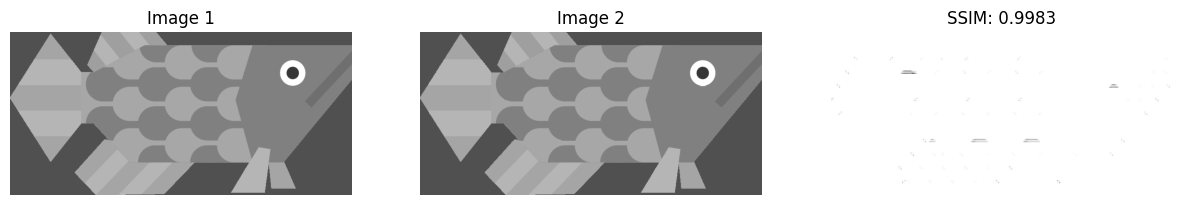

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import cv2


def psnr(original, processed):
    return cv2.PSNR(original, processed)


def nae(original, processed):
    # Ensure the images are in floating point format to avoid integer overflow
    original = original.astype(np.float64)
    processed = processed.astype(np.float64)

    numerator = np.sum(np.abs(original - processed))
    denominator = np.sum(np.abs(original))
    return numerator / denominator


def cc(original, processed):
    original = original.flatten()
    processed = processed.flatten()
    cc = np.corrcoef(original, processed)[0, 1]
    return cc


# def cc(original, processed):
#     return np.sum(original * processed) / np.sum(original * original)

def lmse(original, processed):
    laplacian_original = cv2.Laplacian(original, cv2.CV_64F)
    laplacian_processed = cv2.Laplacian(processed, cv2.CV_64F)
    mse = np.mean((laplacian_original - laplacian_processed) ** 2)
    return mse


def mse(original, processed):
    # the 'Mean Squared Error' between the two images is the
    # sum of the squared difference between the two images;
    # NOTE: the two images must have the same dimension
    err = np.sum((original.astype("float") - processed.astype("float")) ** 2)
    err /= float(original.shape[0] * original.shape[1])

    # return the MSE, the lower the error, the more "similar"
    # the two images are
    return err


def re(original, processed):
    re = np.sum(np.abs(original - processed)) / np.sum(np.abs(original))
    return re


# Load the pixel data for the two images
data1 = np.loadtxt('input360.txt')
data2 = np.loadtxt('output360.txt')

# Ensure the data is in the correct format (2D for grayscale, 3D for RGB)
# Assuming grayscale images; otherwise, adjust as necessary.
print(data1.shape, data2.shape)
if data1.shape != data2.shape:
    raise ValueError("The two images must have the same dimensions")

# Calculate the SSIM score
ssim_score, diff = ssim(data1, data2, full=True, data_range=data1.max() - data1.min())

# Display the original images and the SSIM difference map
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(data1, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Image 1')
ax[0].axis('off')

ax[1].imshow(data2, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Image 2')
ax[1].axis('off')

ax[2].imshow(diff, cmap='gray')
ax[2].set_title(f'SSIM: {ssim_score:.4f}')
ax[2].axis('off')

plt.show()


In [10]:
import numpy as np
import cv2

# Load data
data1 = np.loadtxt('input360.txt').astype(np.float64)  # Convert to float64
data2 = np.loadtxt('output360.txt').astype(np.float64)  # Convert to float64

# Your existing functions using the correct data type
def psnr(original, processed):
    return cv2.PSNR(original, processed)

def nae(original, processed):
    numerator = np.sum(np.abs(original - processed))
    denominator = np.sum(np.abs(original))
    return numerator / denominator

def cc(original, processed):
    original = original.flatten()
    processed = processed.flatten()
    return np.corrcoef(original, processed)[0, 1]

def lmse(original, processed):
    laplacian_original = cv2.Laplacian(original, cv2.CV_64F)
    laplacian_processed = cv2.Laplacian(processed, cv2.CV_64F)
    return np.mean((laplacian_original - laplacian_processed) ** 2)

def mse(original, processed):
    err = np.sum((original - processed) ** 2)
    err /= float(original.shape[0] * original.shape[1])
    return err

def re(original, processed):
    return np.sum(np.abs(original - processed)) / np.sum(np.abs(original))

# Example of how to call and print the metrics
print(f"PSNR: {psnr(data1, data2):.2f} dB")
print(f"NAE: {nae(data1, data2):.4f}")
print(f"CC: {cc(data1, data2):.4f}")
print(f"LMSE: {lmse(data1, data2):.4f}")
print(f"MSE: {mse(data1, data2):.4f}")
print(f"RE: {re(data1, data2):.4f}")



original_image = cv2.imread("assets/fish_360.png", cv2.IMREAD_GRAYSCALE)
processed_image = cv2.imread("lmao.png", cv2.IMREAD_GRAYSCALE)
print(f"\n\nPSNR: {psnr(original_image, processed_image):.2f} dB")
print(f"NAE: {nae(original_image, processed_image):.4f}")
print(f"CC: {cc(original_image, processed_image):.4f}")
print(f"LMSE: {lmse(original_image, processed_image):.4f}")
print(f"MSE: {mse(original_image, processed_image):.4f}")
print(f"RE: {re(original_image, processed_image):.4f}")



PSNR: 45.29 dB
NAE: 0.0002
CC: 0.9994
LMSE: 18.9250
MSE: 1.9252
RE: 0.0002


PSNR: 45.09 dB
NAE: 0.0008
CC: 0.9994
LMSE: 19.8364
MSE: 0.1125
RE: 0.0008


## Error analysis draft 1

{'PSNR': {'benchmark': [27.88085271231428, 29.82918315030325, 27.556943505848924, 37.28126369325731, 26.43241285991757, 16.002848328954247], 'dlr': [25.949866104330436, 28.156388627251445, 25.732613110066236, 36.34062385326417, 26.20933609391941, 14.97619790203256], 'linear': [27.88085271231428, 29.82918315030325, 27.556943505848924, 37.28126369325731, 26.43241285991757, 16.002848328954247]}, 'NAE': {'benchmark': [0.05360461761116551, 0.048925028520678, 0.046838432129885324, 0.019713301231152763, 0.07468576839744774, 0.18106744474302422], 'dlr': [0.06258391398026263, 0.05484028266343458, 0.055145526401217324, 0.020095385777936174, 0.07775437664814312, 0.18944083669611378], 'linear': [0.05360461761116551, 0.048925028520678, 0.046838432129885324, 0.019713301231152763, 0.07468576839744774, 0.18106744474302422]}, 'CC': {'benchmark': [0.9915658890213919, 0.9901271015844848, 0.9919520605718278, 0.9958206724551051, 0.9807363199161093, 0.931944203095162], 'dlr': [0.9868997030053759, 0.98554176

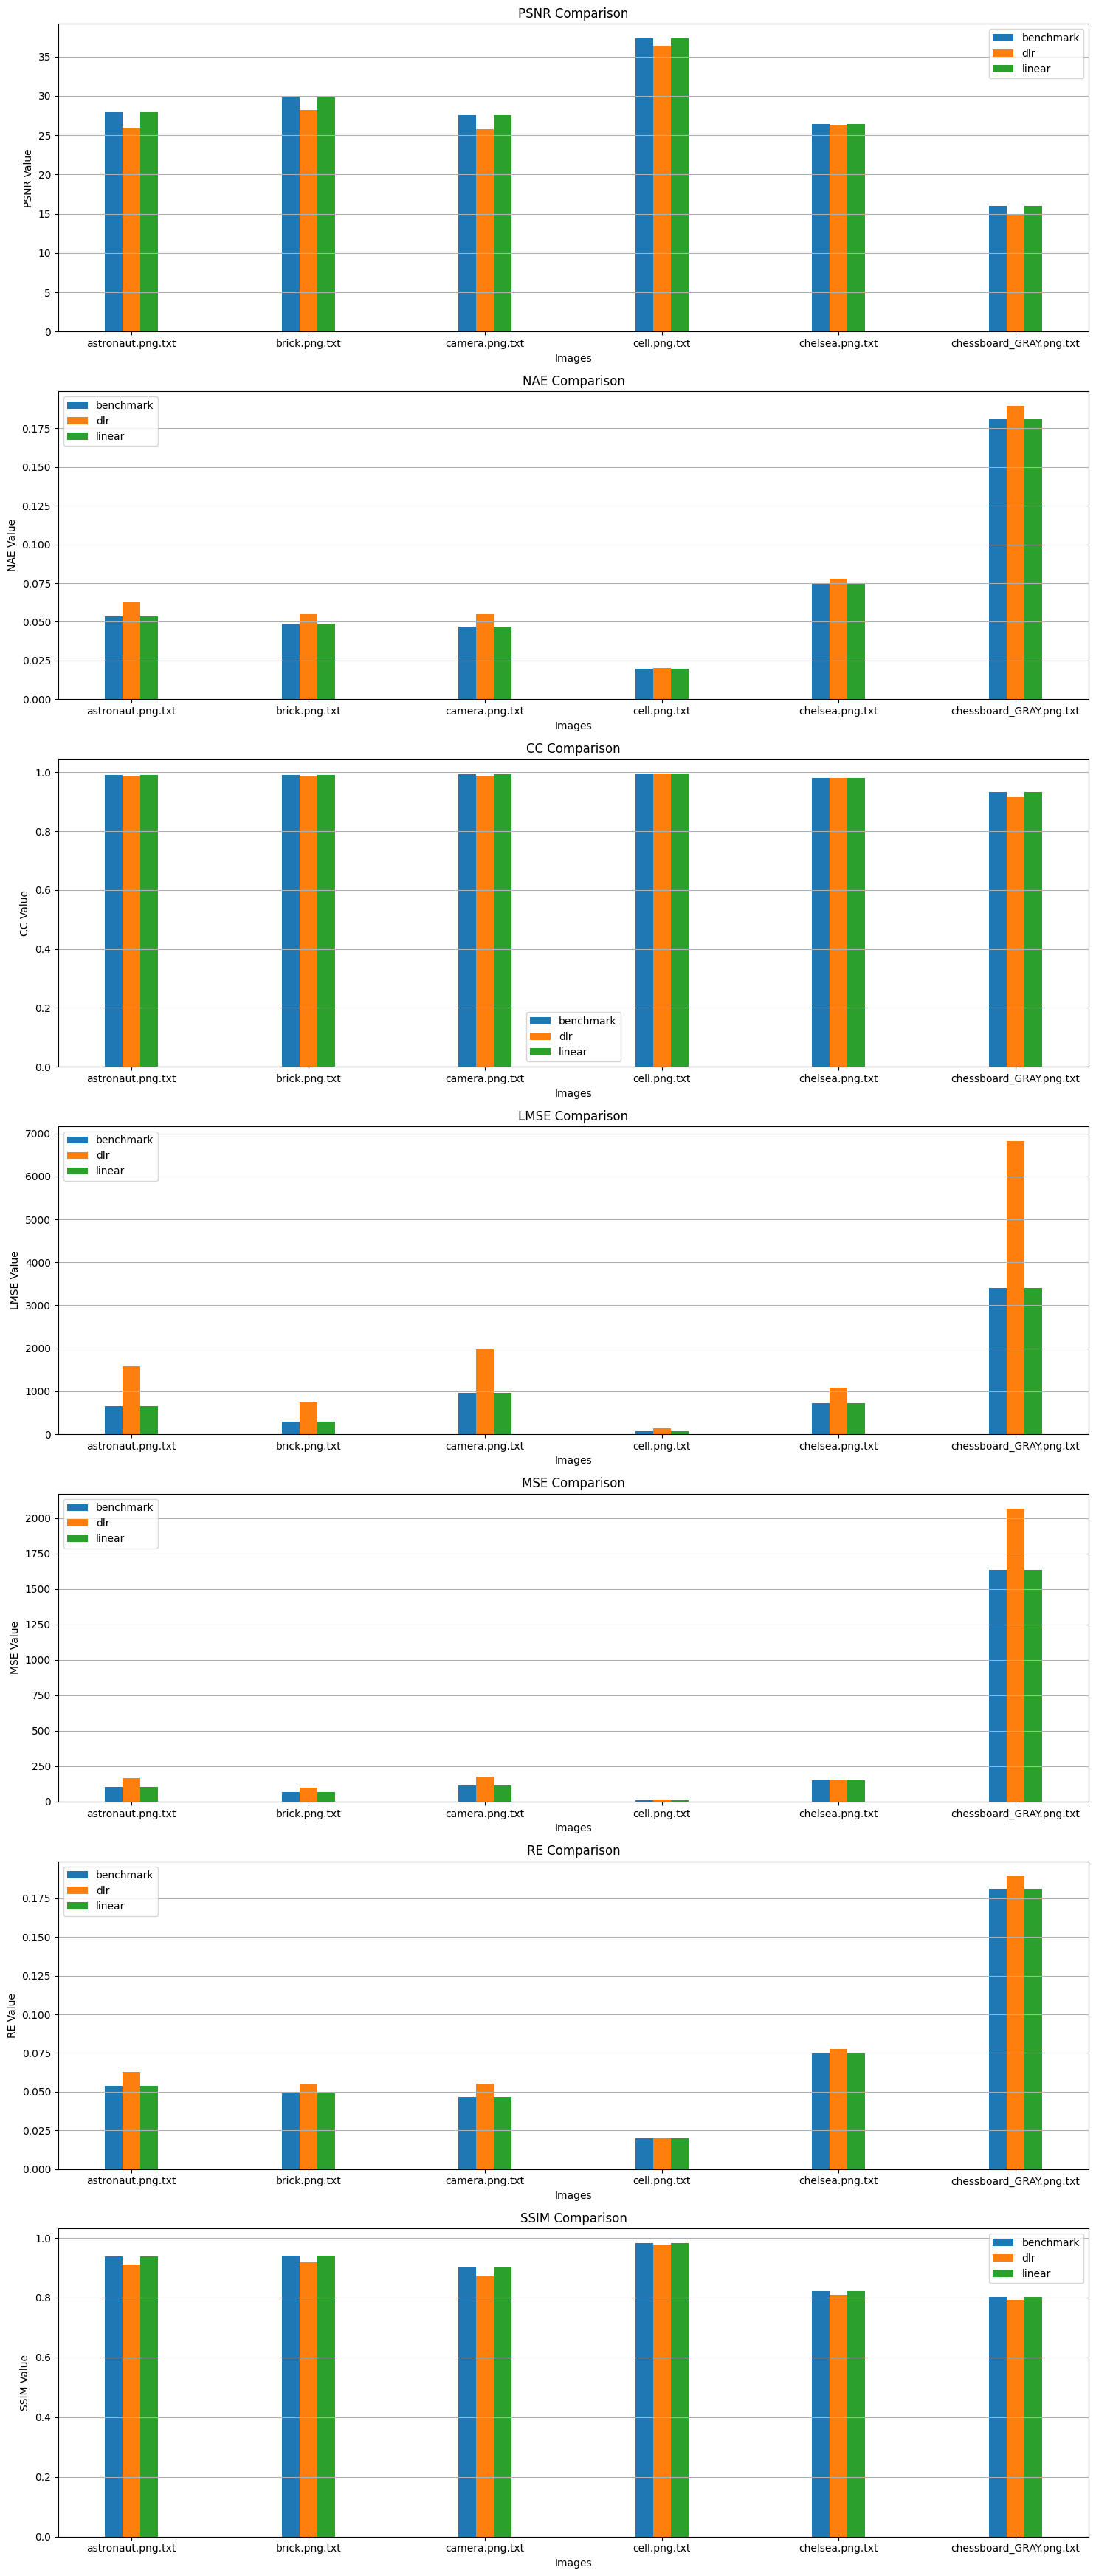

In [1]:
import json
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import csv
from datetime import datetime
import pickle

def psnr(original, processed):
    return cv2.PSNR(original, processed)

def nae(original, processed):
    numerator = np.sum(np.abs(original - processed))
    denominator = np.sum(np.abs(original))
    return numerator / denominator

def cc(original, processed):
    original = original.flatten()
    processed = processed.flatten()
    return np.corrcoef(original, processed)[0, 1]

def lmse(original, processed):
    laplacian_original = cv2.Laplacian(original, cv2.CV_64F)
    laplacian_processed = cv2.Laplacian(processed, cv2.CV_64F)
    mse = np.mean((laplacian_original - laplacian_processed) ** 2)
    return mse

def mse(original, processed):
    err = np.sum((original.astype("float") - processed.astype("float")) ** 2)
    err /= float(original.shape[0] * original.shape[1])
    return err

def re(original, processed):
    return np.sum(np.abs(original - processed)) / np.sum(np.abs(original))

# Load the JSON data
with open("logs/stuff_tested.json", mode="r", encoding="utf-8") as f:
    data = json.load(f)

# Initialize the results dictionary classified by metric
metrics = ["PSNR", "NAE", "CC", "LMSE", "MSE", "RE", "SSIM"]
results = {metric: {method: [] for method in [_.split("/")[-1][:-3] for _ in data["binaries"]]} for metric in metrics}

# Process each image and binary
for img_path in data["input_images"]:
    original_image = np.loadtxt(img_path).astype(np.float64)

    for method in results["PSNR"].keys():
        out_path = os.path.join(f"./dumps/out/{method}__b_{img_path.split('/')[-1]}")
        processed_image = np.loadtxt(out_path).astype(np.float64)

        max_w = max(original_image.shape[0], processed_image.shape[0])
        max_h = max(original_image.shape[1], processed_image.shape[1])
        target_shape = (max_w, max_h)

        og_new = np.zeros(target_shape)
        og_new[:original_image.shape[0], :original_image.shape[1]] = original_image
        processed_new = np.zeros(target_shape)
        processed_new[:processed_image.shape[0], :processed_image.shape[1]] = processed_image

        # Store results under each metric
        results["PSNR"][method].append(psnr(og_new, processed_new))
        results["NAE"][method].append(nae(og_new, processed_new))
        results["CC"][method].append(cc(og_new, processed_new))
        results["LMSE"][method].append(lmse(og_new, processed_new))
        results["MSE"][method].append(mse(og_new, processed_new))
        results["RE"][method].append(re(og_new, processed_new))
        results["SSIM"][method].append(ssim(og_new, processed_new, data_range=og_new.max() - og_new.min()))

print(results)
# Plot the results classified by metric
num_metrics = len(metrics)
fig, axs = plt.subplots(num_metrics, 1, figsize=(15, 5 * num_metrics))

# Create directory for logs if it doesn't exist
os.makedirs('logs', exist_ok=True)

csv_filename = f'logs/error_analysis_results_{datetime.now().strftime("%b%d_%H_%M")}.csv'
csv_data = []

for idx, metric in enumerate(metrics):
    ax = axs[idx] if num_metrics > 1 else axs  # Handle case with only one subplot
    
    # Plot each method for the given metric as a bar graph
    bar_width = 0.1
    indices = np.arange(len(data["input_images"]))
    
    for i, method in enumerate(results[metric].keys()):
        values = results[metric][method]
        ax.bar(indices + i * bar_width, values, bar_width, label=method)
    
    ax.set_xlabel('Images')
    ax.set_ylabel(f'{metric} Value')
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(indices + bar_width * (len(results[metric]) - 1) / 2)
    ax.set_xticklabels([img.split('/')[-1] for img in data["input_images"]])
    ax.legend()
    ax.grid(True, axis='y')

# Adjust layout and save plot using pickle
plt.tight_layout()
pickle_filename = f'logs/error_analysis_plt_{datetime.now().strftime("%b%d_%H_%M")}.fig.pickle'
with open(pickle_filename, 'wb') as f:
    pickle.dump(fig, f)

# Save the results in a CSV file, classified by metric
with open(csv_filename, 'w', newline='') as f:
    writer = csv.writer(f)
    
    for metric in metrics:
        writer.writerow([f'{metric}:'])
        writer.writerow(['Method'] + [img.split('/')[-1] for img in data["input_images"]])
        
        for method in results[metric].keys():
            row = [method] + results[metric][method]
            writer.writerow(row)
        
        writer.writerow([])

print(f"Plot saved as {pickle_filename}")
print(f"Data saved as {csv_filename}")


# --- FINAL EVALUATION ---

comparing ./assets/tests/astronaut.png and ./outputs/affine_transform__b_astronaut.png
comparing ./assets/tests/astronaut.png and ./outputs/benchmark_custom__b_astronaut.png
comparing ./assets/tests/astronaut.png and ./outputs/benchmark__b_astronaut.png
comparing ./assets/tests/astronaut.png and ./outputs/bicubic__b_astronaut.png
comparing ./assets/tests/astronaut.png and ./outputs/lanczos__b_astronaut.png
comparing ./assets/tests/astronaut.png and ./outputs/linear__b_astronaut.png
comparing ./assets/tests/astronaut.png and ./outputs/nearest__b_astronaut.png
comparing ./assets/tests/astronaut.png and ./outputs/proposed_algorithm__b_astronaut.png
comparing ./assets/tests/brick.png and ./outputs/affine_transform__b_brick.png
comparing ./assets/tests/brick.png and ./outputs/benchmark_custom__b_brick.png
comparing ./assets/tests/brick.png and ./outputs/benchmark__b_brick.png
comparing ./assets/tests/brick.png and ./outputs/bicubic__b_brick.png
comparing ./assets/tests/brick.png and ./outpu

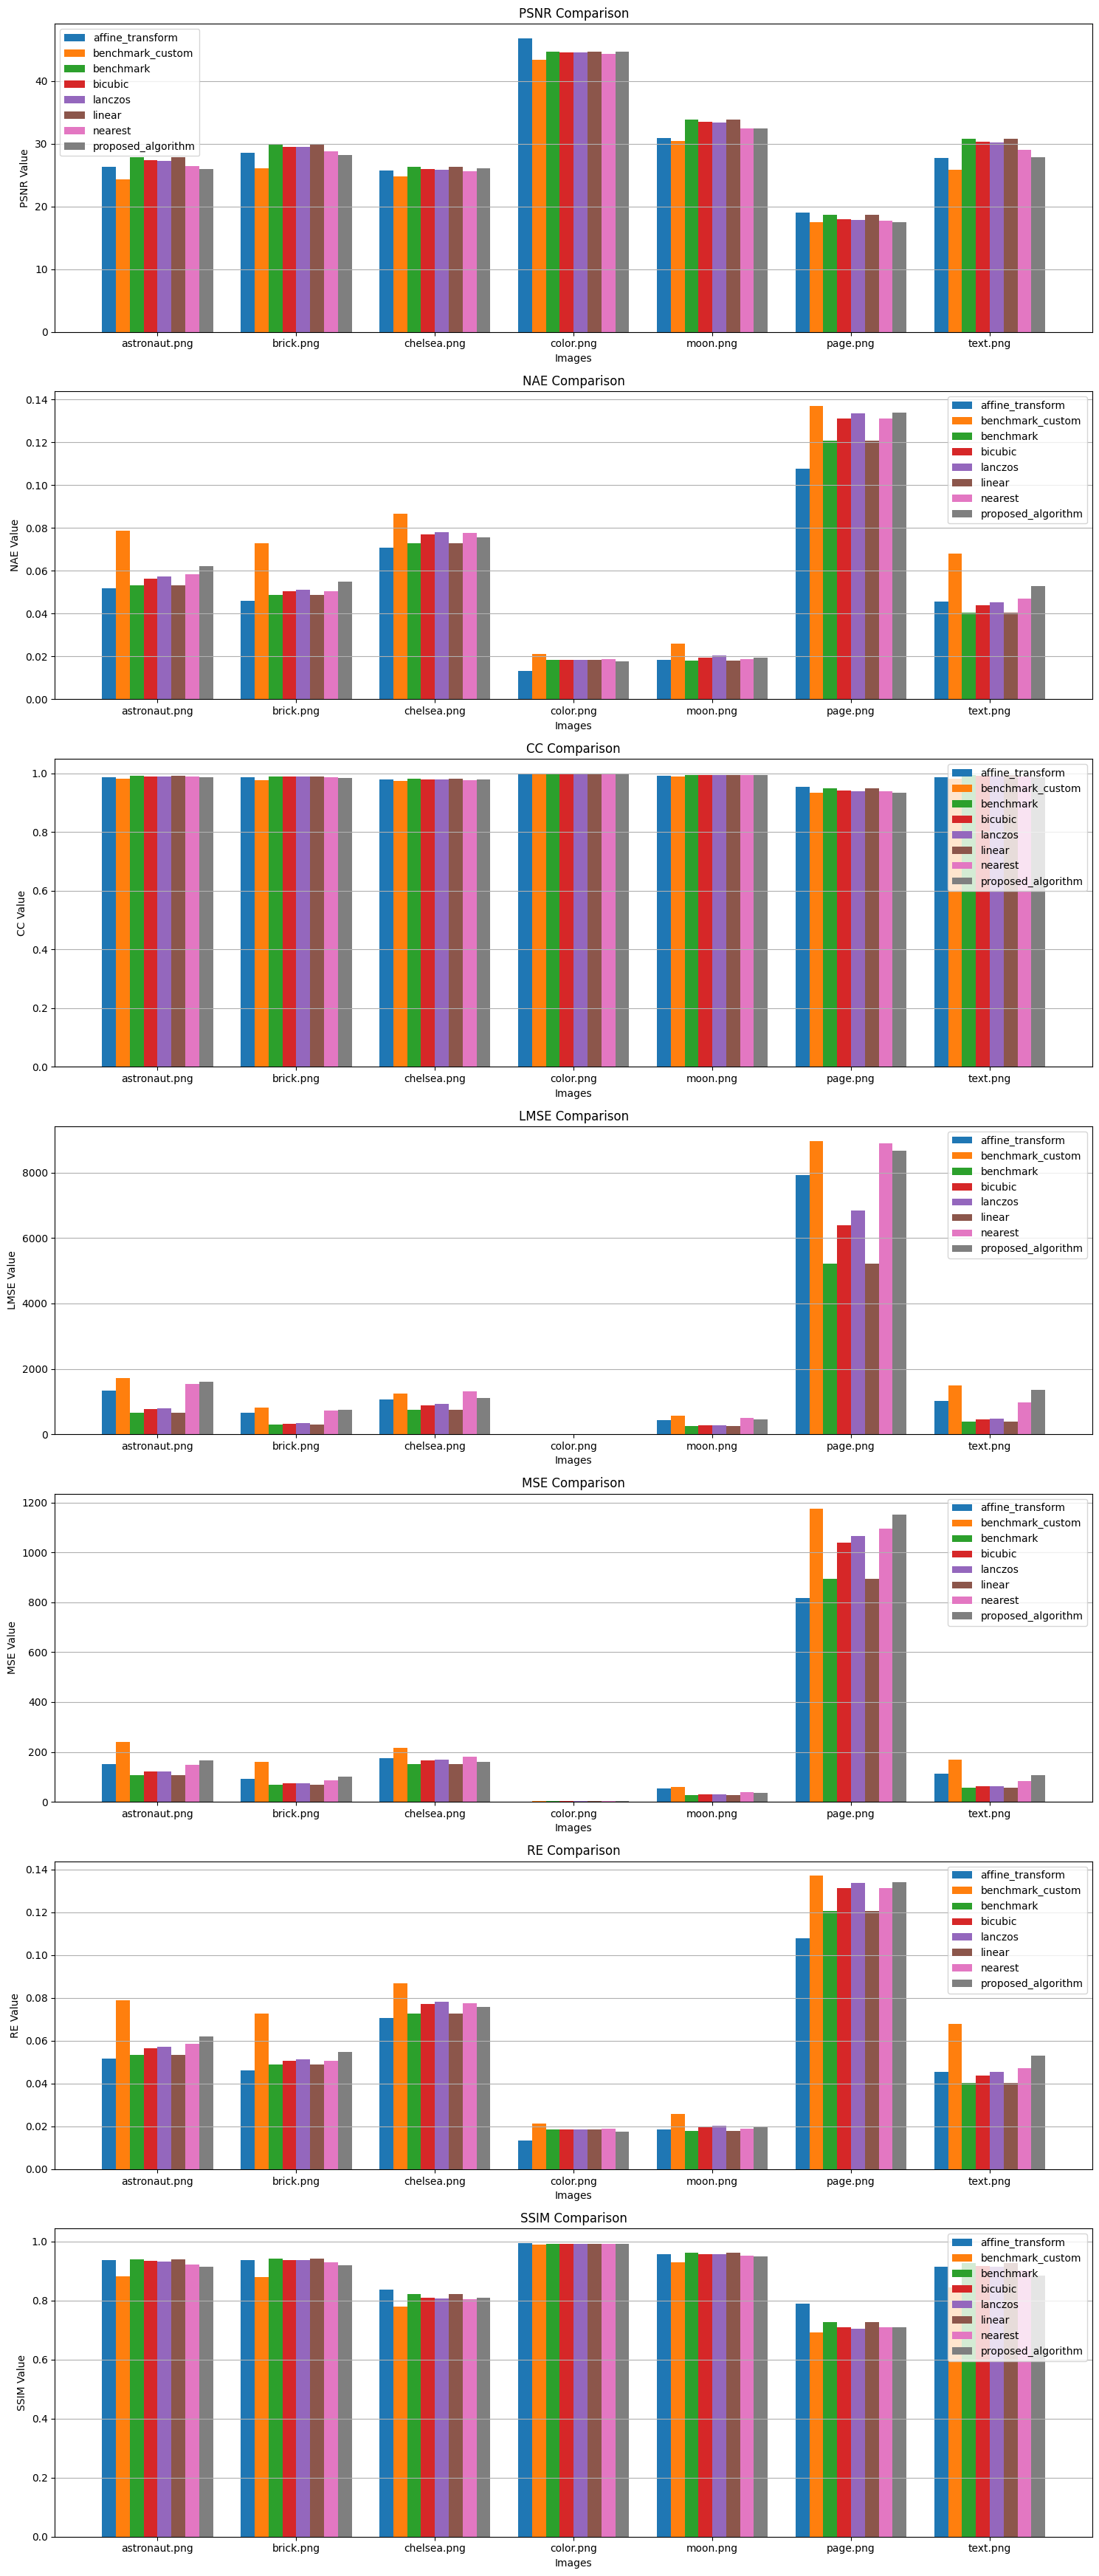

In [8]:
import json
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import csv
from datetime import datetime
import pickle

def psnr(original, processed):
    return cv2.PSNR(original, processed)

def nae(original, processed):
    numerator = np.sum(np.abs(original - processed))
    denominator = np.sum(np.abs(original))
    return numerator / denominator

def cc(original, processed):
    original = original.flatten()
    processed = processed.flatten()
    return np.corrcoef(original, processed)[0, 1]

def lmse(original, processed):
    laplacian_original = cv2.Laplacian(original, cv2.CV_64F)
    laplacian_processed = cv2.Laplacian(processed, cv2.CV_64F)
    mse = np.mean((laplacian_original - laplacian_processed) ** 2)
    return mse

def mse(original, processed):
    err = np.sum((original.astype("float") - processed.astype("float")) ** 2)
    err /= float(original.shape[0] * original.shape[1])
    return err

def re(original, processed):
    return np.sum(np.abs(original - processed)) / np.sum(np.abs(original))

# Load the JSON data
with open("logs/stuff_tested.json", mode="r", encoding="utf-8") as f:
    data = json.load(f)

# Initialize the results dictionary classified by metric
metrics = ["PSNR", "NAE", "CC", "LMSE", "MSE", "RE", "SSIM"]
results = {metric: {method: [] for method in [_.split("/")[-1][:-3] for _ in data["binaries"]]} for metric in metrics}

# Process each image and binary
for img_path in data["input_images"]:
    original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


    for method in results["PSNR"].keys():
        out_path = os.path.join(f"./outputs/{method}__b_{img_path.split('/')[-1]}")
        processed_image = cv2.imread(out_path, cv2.IMREAD_GRAYSCALE)

        max_w = max(original_image.shape[0], processed_image.shape[0])
        max_h = max(original_image.shape[1], processed_image.shape[1])
        target_shape = (max_w, max_h)

        og_new = np.zeros(target_shape)
        og_new[:original_image.shape[0], :original_image.shape[1]] = original_image
        processed_new = np.zeros(target_shape)
        processed_new[:processed_image.shape[0], :processed_image.shape[1]] = processed_image

        print(f"comparing {img_path} and {out_path}")
        # Store results under each metric
        results["PSNR"][method].append(psnr(og_new, processed_new))
        results["NAE"][method].append(nae(og_new, processed_new))
        results["CC"][method].append(cc(og_new, processed_new))
        results["LMSE"][method].append(lmse(og_new, processed_new))
        results["MSE"][method].append(mse(og_new, processed_new))
        results["RE"][method].append(re(og_new, processed_new))
        results["SSIM"][method].append(ssim(og_new, processed_new, data_range=og_new.max() - og_new.min()))

# Plot the results classified by metric
num_metrics = len(metrics)
fig, axs = plt.subplots(num_metrics, 1, figsize=(15, 5 * num_metrics))

# Create directory for logs if it doesn't exist
os.makedirs('logs', exist_ok=True)

csv_filename = f'logs/error_analysis_results_{datetime.now().strftime("%b%d_%H_%M")}.csv'
csv_data = []

for idx, metric in enumerate(metrics):
    ax = axs[idx] if num_metrics > 1 else axs  # Handle case with only one subplot
    
    # Plot each method for the given metric as a bar graph
    bar_width = 0.1
    indices = np.arange(len(data["input_images"]))
    
    for i, method in enumerate(results[metric].keys()):
        values = results[metric][method]
        ax.bar(indices + i * bar_width, values, bar_width, label=method)
    
    ax.set_xlabel('Images')
    ax.set_ylabel(f'{metric} Value')
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(indices + bar_width * (len(results[metric]) - 1) / 2)
    ax.set_xticklabels([img.split('/')[-1] for img in data["input_images"]])
    ax.legend()
    ax.grid(True, axis='y')

# Adjust layout and save plot using pickle
plt.tight_layout()
pickle_filename = f'logs/error_analysis_plt_{datetime.now().strftime("%b%d_%H_%M")}.fig.pickle'
with open(pickle_filename, 'wb') as f:
    pickle.dump(fig, f)

# Save the results in a CSV file, classified by metric
with open(csv_filename, 'w', newline='') as f:
    writer = csv.writer(f)
    
    for metric in metrics:
        writer.writerow([f'{metric}:'])
        writer.writerow(['Method'] + [img.split('/')[-1] for img in data["input_images"]])
        
        for method in results[metric].keys():
            row = [method] + results[metric][method]
            writer.writerow(row)
        
        writer.writerow([])

print(f"Plot saved as {pickle_filename}")
print(f"Data saved as {csv_filename}")
